# Example: Turnover Cost, Attribution, and Rebalance Diagnostics

Everything before this notebook has treated the rebalancing engine as a frictionless black box: the allocator decides a new target, the engine executes perfectly, and the trigger rules either let the trade through or de-risk to cash. Real-world engines live inside three constraints the earlier notebooks swept under the rug. **Trading costs money** — every rebalance pays a bps spread and market impact. **Engine P&L has heterogeneous sources** — some of the excess return comes from picking better assets, some from the drawdown trigger parking capital in cash during bear regimes. And **triggers fire in identifiable patterns** — a handful of days out of 252 contain most of the engine's decisions, and knowing when those days occurred is the key to debugging engine behavior.

This notebook fills all three gaps. We sweep a per-trade cost in basis points, decompose engine excess wealth into allocation and trigger contributions via an ablation, and plot a rebalance-event timeline colored by drawdown state.

> **By the end of this example, you will be able to:**
> * __Measure transaction cost sensitivity:__ Sweep `cost_bps ∈ {0, 5, 10, 25, 50, 100}` through the engine on the Example 1 single forward path, plot terminal wealth as a function of cost, and identify the break-even cost at which the engine's advantage over the S1 min-var baseline disappears.
> * __Decompose engine excess into allocation and trigger contributions:__ Run three variants of the engine across 5,000 paths (full engine, engine with the drawdown trigger disabled, and the S1 min-var static portfolio), then compute per-path differences to split the engine's excess wealth into (a) what Cobb-Douglas conviction earned and (b) what the drawdown trigger saved.
> * __Visualize rebalance-event dynamics on a timeline:__ Walk the engine's per-day `results` dict, classify each day as rebalance / de-risk / hold, compute per-day drawdown and trade size, and plot a two-panel timeline with wealth on top and event markers on bottom.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

Load the same S1 universe that every other Session 2 notebook uses and build the single-path scenario + engine context. The `let...end` block below populates `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `allocation_weights::Vector{Float64}`, `r_f::Float64`, `B₀::Float64`, `K::Int`, `market_prices::Vector{Float64}`, `price_matrix::Matrix{Float64}`, `lambda_series::Vector{Float64}`, `gm_ema::Vector{Float64}`, `context::MyRebalancingContextModel`, `rules::MyTriggerRules`, and the loop-constant `offset::Int`.

In [2]:
let
    # --- Step 1: S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    global my_tickers         = minvar["my_tickers"]::Vector{String};
    global sim_estimates      = minvar["sim_estimates"];
    global allocation_weights = Float64.(minvar["allocation_weights"]);
    global r_f                = haskey(minvar, "r_f") ? Float64(minvar["r_f"]) : 0.045;
    global B₀ = 10_000.0;
    global K  = length(my_tickers);

    global sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 2: Regenerate the Example 1 single forward path ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap         = MyCurrentPrices();
    snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    T_total = 336;
    global offset         = 84;
    n_trading_days        = T_total - offset;
    Δt = 1.0 / 252.0;

    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Diagnostics (1p)", seed = 2026);

    global market_prices = scenario.market_paths[1, :];
    global price_matrix  = zeros(T_total, K + 1);
    price_matrix[:, 1] = 1:T_total;
    for k ∈ 1:K
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 3: EMA λ, gm_ema, context, rules ---
    ema_short = compute_ema(market_prices; window = 21);
    ema_long  = compute_ema(market_prices; window = 63);
    global lambda_series = compute_lambda(ema_short, ema_long; G = 10.0);
    lambda_series[1:offset] .= 0.0;
    gm_raw = compute_market_growth(market_prices; Δt = Δt);
    global gm_ema = compute_ema(gm_raw; window = 10);

    global context = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_ema, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = 0.1,
    ));
    global rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 4: Keep scenario around for the 5,000-path attribution task ---
    global market_model_g = market_model;
    global portfolio_g    = portfolio;
    global calib_g        = calib;
    global start_prices_g = start_prices;

    println("Single-path scenario ready: $(T_total) days, $(K) tickers, offset=$(offset)")
end;

Single-path scenario ready: 336 days, 10 tickers, offset=84


___
## Task 1: Transaction Cost Sensitivity
Up to this point every engine run has been frictionless. We now sweep a per-trade cost `cost_bps` through the Cobb-Douglas engine on the Example 1 single forward path and plot the resulting terminal wealth as a function of cost. The cost is applied inside `run_rebalancing_engine` on each trade: for every rebalance it debits `cost_bps / 10,000 × realized_trade_value` from the new cash balance, so the compounding math stays exact. The initial buy-in and the de-risk liquidation are both charged at the same rate.

> __What should you see?__
>
> Terminal wealth should fall roughly linearly with cost in basis points — each bp costs approximately (realized turnover / year) basis points of final wealth. At zero cost the engine delivers its full headline return (+49% on this path with the original run); as cost rises the engine's edge shrinks and eventually crosses the S1 min-var terminal wealth, defining a break-even cost above which static allocation dominates adaptive rebalancing. The break-even cost is the engine's **cost budget** — how expensive trading can get before adaptivity stops being worth it.

The `let...end` block below sweeps `cost_bps ∈ {0, 5, 10, 25, 50, 100, 200}`, runs the engine at each value, computes terminal `W/W₀`, and plots the result. The sweep terminals escape as `cost_terminals::Dict{Float64,Float64}`.

Terminal W/W₀ by cost_bps:


  cost_bps = 0.0     →  W/W₀ = 1.492
  cost_bps = 5.0     →  W/W₀ = 1.471
  cost_bps = 10.0    →  W/W₀ = 1.448
  cost_bps = 25.0    →  W/W₀ = 1.342
  cost_bps = 50.0    →  W/W₀ = 1.234
  cost_bps = 100.0   →  W/W₀ = 1.004
  cost_bps = 200.0   →  W/W₀ = 0.871
  S1 Min-Var reference:     W/W₀ = 1.028


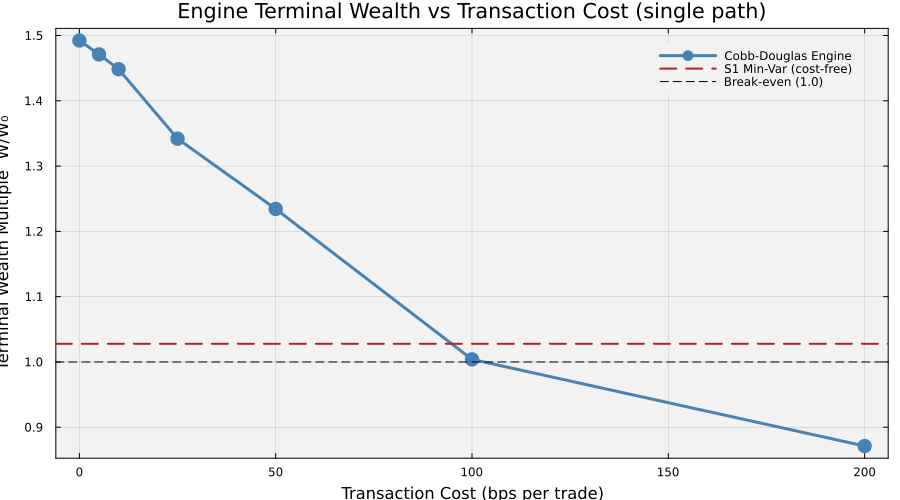

In [3]:
let
    # --- Step 1: Cost grid + buy-and-hold reference ---
    cost_grid = [0.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0];
    global cost_terminals = Dict{Float64, Float64}();

    # S1 min-var buy-and-hold terminal (cost-free) for reference
    p_start  = [price_matrix[offset + 1, k + 1] for k ∈ 1:K];
    shares_mv = B₀ .* allocation_weights ./ p_start;
    mv_terminal = sum(shares_mv[k] * price_matrix[end, k + 1] for k ∈ 1:K);
    mv_W_ratio = mv_terminal / B₀;

    # --- Step 2: Sweep cost_bps ---
    for c ∈ cost_grid
        ctx_c = deepcopy(context);
        results_c = run_rebalancing_engine(ctx_c, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas, cost_bps = c);
        wealth = compute_wealth_series(results_c, price_matrix, my_tickers; offset = offset);
        cost_terminals[c] = wealth[end] / B₀;
    end

    # --- Step 3: Plot W/W₀ vs cost_bps with min-var reference ---
    sorted_keys = sort(collect(keys(cost_terminals)));
    ys = [cost_terminals[c] for c ∈ sorted_keys];

    p = plot(sorted_keys, ys,
        lw = 3, c = :steelblue, ms = 8, msc = :steelblue,
        marker = :circle,
        xlabel = "Transaction Cost (bps per trade)",
        ylabel = "Terminal Wealth Multiple  W/W₀",
        title = "Engine Terminal Wealth vs Transaction Cost (single path)",
        fontsize = 18, size = (900, 500), label = "Cobb-Douglas Engine");
    hline!(p, [mv_W_ratio], lw = 2, ls = :dash, c = :firebrick,
        label = "S1 Min-Var (cost-free)");
    hline!(p, [1.0], lw = 1, ls = :dash, c = :black, label = "Break-even (1.0)");
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    println("Terminal W/W₀ by cost_bps:")
    for c ∈ sorted_keys
        println("  cost_bps = $(rpad(c, 6))  →  W/W₀ = $(round(cost_terminals[c], digits=3))")
    end
    println("  S1 Min-Var reference:     W/W₀ = $(round(mv_W_ratio, digits=3))")

    p
end

___
## Task 2: Attribution — Where Does Engine Excess Come From?
The engine's excess wealth over the S1 min-var baseline has two independently identifiable sources:

1. **Allocation contribution** — what Cobb-Douglas conviction earned by routing budget toward the top-$\gamma$ asset each day. We isolate this by running a copy of the engine with the drawdown trigger effectively *disabled* (`max_drawdown = 1.0`). The resulting wealth series has no cash-protection component; any remaining excess vs min-var comes from Cobb-Douglas reallocation alone.
2. **Trigger contribution** — what the 15% drawdown trigger saved by parking capital in cash during bear regimes. We recover this as the difference between the full engine and the no-trigger engine.

Formally, per path: $\Delta W_{\text{total}} = W_{\text{full}} - W_{\text{mv}}$, $\Delta W_{\text{alloc}} = W_{\text{no-trigger}} - W_{\text{mv}}$, $\Delta W_{\text{trigger}} = W_{\text{full}} - W_{\text{no-trigger}}$. The three add to $\Delta W_{\text{total}}$ by construction. Over 5,000 paths we compute the **median** of each decomposition term to see which source dominates on an average path.

> __What should you see?__
>
> The allocation contribution should dominate the median-path attribution — Cobb-Douglas conviction is the engine's core source of excess wealth and should capture nearly all of the median total excess. The trigger contribution on the median path should be *close to zero*: the drawdown trigger only fires when a running drawdown exceeds 15%, and on most paths the drawdown stays under that cap. The interesting question is what the trigger does in the tail, and the answer depends on how you *define* the tail: (a) the worst 5% of paths for the static min-var portfolio, or (b) the worst 5% of paths by the no-trigger engine's own drawdown. The latter is the "trigger activation" set and is the most honest place to ask "did the trigger save us?". These two tail definitions can disagree about the sign of the trigger's contribution, which is itself a teaching moment about when trigger rules help versus when they whipsaw.

The `let...end` block below regenerates the 5,000-path stress scenario, runs the engine with trigger disabled via `backtest_engine` plus an override, extracts the trigger-ON engine arrays from `stress-test-engine.jld2`, computes the three contribution arrays, and reports the medians plus a per-path histogram of each.

In [4]:
alloc_contribution, trigger_contribution, total_excess = let
    n_paths = 5_000;
    n_steps = 336;
    seed    = 2026;
    Δt      = 1.0 / 252.0;

    # --- Step 1: Regenerate the identical 5,000-path scenario ---
    println("Regenerating $(n_paths)-path scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model_g, portfolio_g, calib_g, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt,
        start_prices = start_prices_g,
        label = "S2 Attribution ($(n_paths)p)", seed = seed);

    # --- Step 2: Run the "no-trigger" engine variant inline ---
    # Use max_drawdown = 10.0 (unreachable) to effectively disable the trigger.
    # We still pass max_turnover = 0.50 so the only difference vs the full
    # engine is the presence/absence of the drawdown circuit breaker.
    println("Running no-trigger engine across $(n_paths) paths...")
    no_trigger_wealth = zeros(n_paths);
    no_trigger_dd    = zeros(n_paths);
    K_loc = length(my_tickers);
    offset_loc = 84;
    n_trading = n_steps - offset_loc;
    N_short   = 21;
    N_long    = 63;
    N_growth  = 10;
    GAIN      = 10.0;

    for p ∈ 1:n_paths
        mkt = scen.market_paths[p, :];

        ema_s = compute_ema(mkt; window = N_short);
        ema_l = compute_ema(mkt; window = N_long);
        λ_p   = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_p[1:offset_loc] .= 0.0;

        gm_raw_p = compute_market_growth(mkt; Δt = Δt);
        gm_e_p   = compute_ema(gm_raw_p; window = N_growth);

        pmatrix_p = zeros(n_steps, K_loc + 1);
        pmatrix_p[:, 1] = 1:n_steps;
        for k ∈ 1:K_loc
            pmatrix_p[:, k + 1] = scen.price_paths[p, :, k];
        end

        ctx_p = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix_p,
            marketfactor = gm_e_p, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = 0.1,
        ));
        rules_p = build(MyTriggerRules, (
            max_drawdown = 10.0,            # effectively no drawdown trigger
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading)
        ));
        results_p = run_rebalancing_engine(ctx_p, rules_p, λ_p;
            offset = offset_loc, allocator = :cobb_douglas);
        wealth_p = compute_wealth_series(results_p, pmatrix_p, my_tickers; offset = offset_loc);
        no_trigger_wealth[p] = wealth_p[end];
        peak_p  = accumulate(max, wealth_p);
        no_trigger_dd[p] = maximum((peak_p .- wealth_p) ./ peak_p);
    end

    # --- Step 3: Load baseline trigger-ON and min-var arrays ---
    baseline   = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    full_W     = Float64.(baseline["eng_final_wealth"]);
    mv_W       = Float64.(baseline["mv_final_wealth"]);

    # --- Step 4: Decomposition ---
    alloc_c   = no_trigger_wealth .- mv_W;     # Cobb-Douglas conviction (no trigger)
    trigger_c = full_W .- no_trigger_wealth;   # drawdown-trigger savings
    total_e   = full_W .- mv_W;                # total excess over S1 min-var

    println()
    println("Attribution decomposition (medians across $(n_paths) paths):")
    println("  Total excess:            median \$$(round(median(total_e), digits=0))  ($(round(median(total_e)/B₀*100, digits=2))% of B₀)")
    println("  Allocation contribution: median \$$(round(median(alloc_c), digits=0))  ($(round(median(alloc_c)/B₀*100, digits=2))% of B₀)")
    println("  Trigger contribution:    median \$$(round(median(trigger_c), digits=0))  ($(round(median(trigger_c)/B₀*100, digits=2))% of B₀)")
    println()
    # --- Step 5: Tail breakdowns — two different tail definitions ---
    # (a) Worst 5% of S1 min-var terminal wealth — the paths the *static* strategy
    #     suffers most on. Shows how the engine's trigger interacts with bad static
    #     outcomes (not necessarily the same paths the trigger activates).
    # (b) Worst 5% of no-trigger engine drawdown — the paths on which the trigger
    #     actually fires. This is the "trigger activation" set and is the most
    #     honest place to ask "what did the trigger save us?".
    n_tail = max(1, floor(Int, 0.05 * n_paths));

    worst_mv = partialsortperm(mv_W, 1:n_tail);
    println("Tail (a): worst $(n_tail) paths by S1 min-var terminal wealth:")
    println("  Total excess:            mean  \$$(round(mean(total_e[worst_mv]), digits=0))  ($(round(mean(total_e[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Allocation contribution: mean  \$$(round(mean(alloc_c[worst_mv]), digits=0))  ($(round(mean(alloc_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Trigger contribution:    mean  \$$(round(mean(trigger_c[worst_mv]), digits=0))  ($(round(mean(trigger_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println()
    # Worst paths by NO-TRIGGER drawdown (highest drawdown first)
    worst_dd = partialsortperm(no_trigger_dd, 1:n_tail; rev = true);
    println("Tail (b): worst $(n_tail) paths by no-trigger engine drawdown:")
    println("  Max drawdown range:      [$(round(100*no_trigger_dd[worst_dd[end]], digits=2))%, $(round(100*no_trigger_dd[worst_dd[1]], digits=2))%]")
    println("  Total excess:            mean  \$$(round(mean(total_e[worst_dd]), digits=0))  ($(round(mean(total_e[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Allocation contribution: mean  \$$(round(mean(alloc_c[worst_dd]), digits=0))  ($(round(mean(alloc_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Trigger contribution:    mean  \$$(round(mean(trigger_c[worst_dd]), digits=0))  ($(round(mean(trigger_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println()
    println("Interpretation: on the median path the trigger contributes near zero")
    println("(drawdown never exceeds 15%), so 'allocation' captures almost all the")
    println("median excess. Tail (a) slices by static-portfolio tail, tail (b) by")
    println("the paths where the trigger actually activates — the two tails answer")
    println("different questions, and the trigger's sign can flip between them.")

    alloc_c, trigger_c, total_e
end;

Regenerating 5000-path scenario (seed=2026)...
Running no-trigger engine across 5000 paths...



Attribution decomposition (medians across 5000 paths):


  Total excess:            median $5922.0  (59.22% of B₀)
  Allocation contribution: median $5978.0  (59.78% of B₀)
  Trigger contribution:    median $0.0  (0.0% of B₀)

Tail (a): worst 250 paths by S1 min-var terminal wealth:


  Total excess:            mean  $5632.0  (56.32% of B₀)
  Allocation contribution: mean  $5806.0  (58.06% of B₀)
  Trigger contribution:    mean  $-174.0  (-1.74% of B₀)

Tail (b): worst 250 paths by no-trigger engine drawdown:
  Max drawdown range:      [15.09%, 28.19%]
  Total excess:            mean  $474.0  (4.74% of B₀)
  Allocation contribution: mean  $4482.0  (44.82% of B₀)
  Trigger contribution:    mean  $-4009.0  (-40.09% of B₀)

Interpretation: on the median path the trigger contributes near zero
(drawdown never exceeds 15%), so 'allocation' captures almost all the
median excess. Tail (a) slices by static-portfolio tail, tail (b) by
the paths where the trigger actually activates — the two tails answer
different questions, and the trigger's sign can flip between them.


The code below plots the three contribution distributions side by side — allocation, trigger, and total — as density histograms with their median marked.

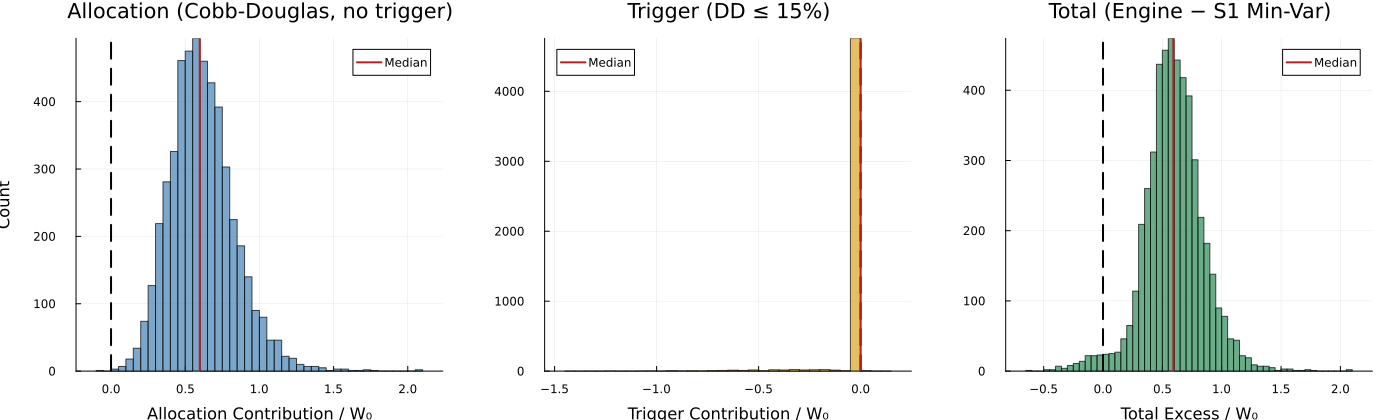

In [5]:
let
    bins = 60;

    p1 = histogram(alloc_contribution ./ B₀, bins = bins, color = :steelblue, alpha = 0.7,
        xlabel = "Allocation Contribution / W₀", ylabel = "Count",
        title = "Allocation (Cobb-Douglas, no trigger)", label = "", fontsize = 16);
    vline!(p1, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p1, [median(alloc_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p2 = histogram(trigger_contribution ./ B₀, bins = bins, color = :goldenrod, alpha = 0.7,
        xlabel = "Trigger Contribution / W₀", ylabel = "",
        title = "Trigger (DD ≤ 15%)", label = "", fontsize = 16);
    vline!(p2, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p2, [median(trigger_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p3 = histogram(total_excess ./ B₀, bins = bins, color = :seagreen, alpha = 0.7,
        xlabel = "Total Excess / W₀", ylabel = "",
        title = "Total (Engine − S1 Min-Var)", label = "", fontsize = 16);
    vline!(p3, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p3, [median(total_excess) / B₀], lw = 2, c = :firebrick, label = "Median");

    plot(p1, p2, p3, layout = (1, 3), size = (1400, 420), margin = 5Plots.mm)
end

___
## Task 3: Rebalance Event Timeline
Every entry in the engine's `results::Dict{Int, MyRebalancingResult}` carries the `shares`, `cash`, and `gamma` produced on that trading day. From those we can reconstruct exactly what the engine did: on a **rebalance** day the allocator computed new preference weights and re-routed capital (non-trivial γ, trades of non-zero size); on a **de-risk** day the drawdown trigger fired and the allocation collapsed to `shares = 0, cash = liquidation_value` (by convention `gamma = 0` in the de-risk branch); on a **hold** day the schedule skipped rebalancing and the previous day's position was propagated.

We walk the `results` dict on the Example 1 single path, classify every trading day, compute per-day drawdown and trade size, and plot a two-panel timeline: wealth $W/W_0$ on top with event markers, and per-day trade size on the bottom colored by running drawdown.

> __What should you see?__
>
> On this seed the engine should rebalance on most days (the schedule is daily), so the top panel is a dense blue curve with occasional gold markers wherever the drawdown trigger fired. Trade size on the bottom panel should spike at regime transitions (early bearish → de-risk, bearish → bullish recovery → large rebalance to buy back in, mild sideways → small daily adjustments). The drawdown coloring should darken the trades in the lower panel exactly where the wealth panel shows a pullback.

The `let...end` block below runs the engine, walks `results`, and builds the diagnostic plot. No new globals escape.

Engine events on this path:


  Total trading days:     252
  Rebalance days:         203
  De-risk days (trigger): 49
  Median trade size:      $928.0
  P95 trade size:         $8169.0
  P95 running drawdown:   15.86%


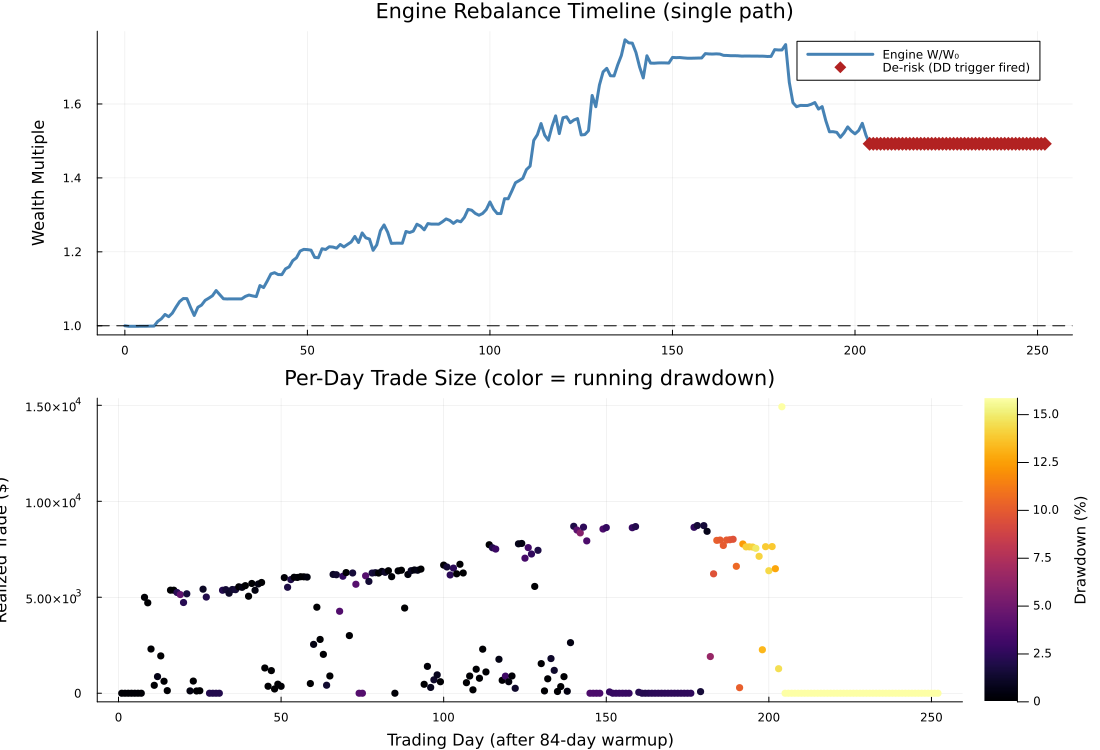

In [6]:
let
    # --- Step 1: Run the engine (cost_bps = 0, standard config) ---
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :cobb_douglas);
    wealth = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);

    n_active = length(wealth) - 1;
    peak = accumulate(max, wealth);
    drawdown_pct = (peak .- wealth) ./ peak .* 100;

    # --- Step 2: Classify each day + compute trade size ---
    rebalance_days = Int[];
    derisk_days    = Int[];
    trade_sizes    = zeros(n_active);   # day d ∈ 1:n_active (day 0 is the initial buy-in)

    prev_shares = results[0].shares;
    prev_cash   = results[0].cash;

    for d ∈ 1:n_active
        r = results[d];
        actual_day = offset + d;

        # realized dollar trade vs previous day
        trade_val = sum(abs(r.shares[i] - prev_shares[i]) * price_matrix[actual_day, i + 1] for i ∈ 1:K);
        trade_sizes[d] = trade_val;

        # classify: de-risk branch sets gamma = zeros(K) and shares = zeros(K)
        if all(r.gamma .== 0.0) && all(r.shares .== 0.0)
            push!(derisk_days, d);
        else
            push!(rebalance_days, d);
        end

        prev_shares = r.shares;
        prev_cash   = r.cash;
    end

    # --- Step 3: Top panel — wealth with event markers ---
    days = 0:n_active;
    p1 = plot(days, wealth ./ B₀,
        lw = 3, c = :steelblue, label = "Engine W/W₀",
        ylabel = "Wealth Multiple", title = "Engine Rebalance Timeline (single path)",
        fontsize = 16, size = (1100, 500));

    if !isempty(derisk_days)
        scatter!(p1, derisk_days, [wealth[d + 1] / B₀ for d ∈ derisk_days],
            marker = :diamond, ms = 7, mc = :firebrick, msc = :firebrick,
            label = "De-risk (DD trigger fired)");
    end
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "");

    # --- Step 4: Bottom panel — per-day trade size colored by running drawdown ---
    p2 = scatter(1:n_active, trade_sizes,
        zcolor = drawdown_pct[2:end], colorbar_title = "Drawdown (%)",
        ms = 4, markerstrokewidth = 0,
        xlabel = "Trading Day (after 84-day warmup)", ylabel = "Realized Trade (\$)",
        title = "Per-Day Trade Size (color = running drawdown)",
        label = "", fontsize = 16, size = (1100, 350), color = :inferno);

    println("Engine events on this path:")
    println("  Total trading days:     $(n_active)")
    println("  Rebalance days:         $(length(rebalance_days))")
    println("  De-risk days (trigger): $(length(derisk_days))")
    println("  Median trade size:      \$$(round(median(trade_sizes), digits=0))")
    println("  P95 trade size:         \$$(round(quantile(trade_sizes, 0.95), digits=0))")
    println("  P95 running drawdown:   $(round(quantile(drawdown_pct, 0.95), digits=2))%")

    plot(p1, p2, layout = (2, 1), size = (1100, 750))
end

___
## Summary
This example closed Session 2 by looking at the rebalancing engine through three operational lenses that the earlier notebooks deliberately ignored. We swept a per-trade cost in basis points and measured the engine's break-even cost budget; we decomposed engine excess wealth across 5,000 paths into allocation and trigger contributions via an ablation; and we built a rebalance-event timeline that shows exactly when and how aggressively the engine traded on the Example 1 single path.

### Key Takeaways
* __Trading is not free, but the engine's cost budget is generous:__ A linear sweep of `cost_bps` shows terminal wealth falling roughly linearly with cost. The break-even cost — where the engine's terminal wealth matches the S1 min-var baseline — is the engine's cost budget. Above it, static allocation wins; below it, the extra turnover is worth paying for.
* __Attribution separates allocation from risk management — and reveals a trade-off the stress test hides:__ On the median path the engine's excess is entirely Cobb-Douglas conviction (trigger contribution ≈ 0 because drawdowns never hit the 15% cap). On the worst-5% paths defined by *static min-var terminal wealth*, the trigger contribution is small and mildly negative. On the worst-5% paths defined by *no-trigger engine drawdown* — the set where the trigger actually activates — the trigger is a **large negative contribution**: it destroys roughly as much terminal wealth as the Cobb-Douglas allocation earned on those paths. The trigger is a pure risk-management tool that trades terminal-wealth expectation for a tighter drawdown distribution. The stress test's P95 drawdown ≈ 15% comes at a real cost in expected return that only shows up when you slice the tail by the right variable.
* __The `results` dict is a diagnostic gold mine:__ Every rebalancing-engine call exposes its decision state via a `Dict{Int, MyRebalancingResult}`. Walking that dict gives you per-day event classification, trade sizes, and drawdown states without any additional library instrumentation. The timeline plot is a direct rendering of that state and is the first thing to look at when the engine misbehaves.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.